# Data Processing Pipeline

This notebook provides a data preparation pipeline for fine-tuning VideoMAE-v2 on the laboratory action videos of the FineBio dataset.

### Dataset Structure
- Videos with multiple action segments per video
- Each video has a corresponding `.txt` annotation file with columns:
  - `start_sec`, `end_sec`: Temporal boundaries of actions
  - `task`, `hand_side`, `verb`, `manipulated_object`, `affected_object`: Action labels

## 1. Setup and Imports

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
import json
import shutil
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("All libraries imported successfully!")
print(f"OpenCV version: {cv2.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully!
OpenCV version: 4.11.0
Pandas version: 2.3.3
NumPy version: 1.26.4


## 2. Configuration

Configure all paths and parameters for the data processing pipeline.

In [5]:
DATASET_ROOT = "/work/team-ai/IRIS/finebio/videos/w640" 
OUTPUT_ROOT = "/work/team-ai/IRIS/finebio/videos/processed"    
LABEL_COLUMN = 'task'  
ANNOTATION_COLUMNS = ['start_sec', 'end_sec', 'task', 'hand_side', 'verb', 
                      'manipulated_object', 'affected_object']
ANNOTATION_DELIMITER = ','
TARGET_FPS = 1              
FRAMES_PER_CLIP = 16       
MIN_SEGMENT_DURATION = 1.0  
MAX_SEGMENT_DURATION = 32.0 
FRAME_SIZE = (224, 224)     

SAMPLING_STRATEGY = 'uniform'

TRAIN_RATIO = 0.7           
VAL_RATIO = 0.15            
TEST_RATIO = 0.15           
RANDOM_SEED = 42            

VIDEO_EXTENSIONS = ['.mp4', '.avi', '.mov', '.mkv', '.MP4', '.AVI', '.MOV', '.MKV']

# Create output directories
os.makedirs(OUTPUT_ROOT, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, 'frames'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, 'metadata'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, 'visualizations'), exist_ok=True)

print("Configuration completed!")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Output root: {OUTPUT_ROOT}")
print(f"Label column: {LABEL_COLUMN}")
print(f"Sampling: {TARGET_FPS} fps, {FRAMES_PER_CLIP} frames per clip")
print(f"Split ratio - Train: {TRAIN_RATIO}, Val: {VAL_RATIO}, Test: {TEST_RATIO}")

Configuration completed!
Dataset root: /work/team-ai/IRIS/finebio/videos/w640
Output root: /work/team-ai/IRIS/finebio/videos/processed
Label column: task
Sampling: 1 fps, 16 frames per clip
Split ratio - Train: 0.7, Val: 0.15, Test: 0.15


## 3. Dataset Scanning and Annotation Parsing

Scan the dataset directory and parse annotation files.

In [4]:
def find_video_annotation_pairs(dataset_root, video_extensions):
    """
    Find all video files and their corresponding annotation files.
    
    Args:
        dataset_root: Path to dataset directory
        video_extensions: List of valid video file extensions
    
    Returns:
        list: List of tuples (video_path, annotation_path)
    """
    pairs = []
    
    if not os.path.exists(dataset_root):
        raise ValueError(f"Dataset root not found: {dataset_root}")
    
    # Find all video files
    for file_name in os.listdir(dataset_root):
        if any(file_name.endswith(ext) for ext in video_extensions):
            video_path = os.path.join(dataset_root, file_name)
            
            # Look for corresponding annotation file
            base_name = os.path.splitext(file_name)[0]
            annotation_path = os.path.join(dataset_root, f"{base_name}.txt")
            
            if os.path.exists(annotation_path):
                pairs.append((video_path, annotation_path))
            else:
                print(f"Warning: No annotation file found for {file_name}")
    
    return sorted(pairs)


def parse_annotation_file(annotation_path, columns, delimiter=','):
    """
    Parse an annotation file.
    
    Args:
        annotation_path: Path to annotation .txt file
        columns: List of column names
        delimiter: Delimiter used in the file
    
    Returns:
        pd.DataFrame: Parsed annotations
    """
    try:
        # Try reading with header
        df = pd.read_csv(annotation_path, delimiter=delimiter)
        
        # If no header, use provided column names
        if not all(col in df.columns for col in columns):
            df = pd.read_csv(annotation_path, delimiter=delimiter, names=columns, header=None)
        
        return df
    except Exception as e:
        print(f"Error parsing {annotation_path}: {e}")
        return None


def create_action_label(row, label_column):
    """
    Create action label from annotation row based on label_column configuration.
    
    Args:
        row: DataFrame row with annotation data
        label_column: Column(s) to use for label (e.g., 'task' or 'verb+object')
    
    Returns:
        str: Action label
    """
    if '+' in label_column:
        # Combine multiple columns
        parts = label_column.split('+')
        values = [str(row[part]).strip() for part in parts if part in row and pd.notna(row[part])]
        return '_'.join(values)
    else:
        # Single column
        return str(row[label_column]).strip() if pd.notna(row[label_column]) else 'unknown'

In [5]:
video_annotation_pairs = find_video_annotation_pairs(DATASET_ROOT, VIDEO_EXTENSIONS)

print(f"Total video-annotation pairs found: {len(video_annotation_pairs)}")

if len(video_annotation_pairs) > 0:
    print("\nFirst 4 pairs:")
    for i, (video_path, annotation_path) in enumerate(video_annotation_pairs[:4], 1):
        print(f"  {i}. Video: {os.path.basename(video_path)}")
        print(f"     Annotation: {os.path.basename(annotation_path)}")

Total video-annotation pairs found: 226

First 4 pairs:
  1. Video: P01_01_01.mp4
     Annotation: P01_01_01.txt
  2. Video: P01_01_02.mp4
     Annotation: P01_01_02.txt
  3. Video: P01_02_01.mp4
     Annotation: P01_02_01.txt
  4. Video: P01_02_02.mp4
     Annotation: P01_02_02.txt


### Parse All Annotations and Create Action Database

In [6]:
def build_action_database(video_annotation_pairs, columns, delimiter, label_column):
    """
    Parse all annotations and build a database of action segments.
    
    Args:
        video_annotation_pairs: List of (video_path, annotation_path) tuples
        columns: Annotation column names
        delimiter: File delimiter
        label_column: Column(s) to use for action labels
    
    Returns:
        pd.DataFrame: Database of all action segments
    """
    all_segments = []
    
    for video_path, annotation_path in tqdm(video_annotation_pairs):
        annotations = parse_annotation_file(annotation_path, columns, delimiter)
        
        if annotations is None or len(annotations) == 0:
            continue
        
        # Get video ID from filename
        video_id = os.path.splitext(os.path.basename(video_path))[0]
        
        # Process each action segment
        for idx, row in annotations.iterrows():
            # Create action label
            action_label = create_action_label(row, label_column)
            
            # Create segment record
            segment = {
                'video_id': video_id,
                'video_path': video_path,
                'segment_id': f"{video_id}_seg{idx:03d}",
                'start_sec': float(row['start_sec']),
                'end_sec': float(row['end_sec']),
                'duration': float(row['end_sec']) - float(row['start_sec']),
                'action_label': action_label,
            }
            
            # Add all original annotation columns
            for col in columns:
                if col not in ['start_sec', 'end_sec']:
                    segment[col] = row[col] if col in row else None
            
            all_segments.append(segment)
    
    return pd.DataFrame(all_segments)

In [7]:
action_db_original = build_action_database(
    video_annotation_pairs,
    ANNOTATION_COLUMNS,
    ANNOTATION_DELIMITER,
    LABEL_COLUMN
)

# Display statistics
print(f"Total action segments: {len(action_db_original)}")
print(f"Total unique videos: {action_db_original['video_id'].nunique()}")
print(f"Total unique action classes: {action_db_original['action_label'].nunique()}")
print(f"\nSegment duration statistics (seconds):")
print(action_db_original['duration'].describe())
print("\nSample action segments:")
print(action_db_original[['segment_id', 'action_label', 'start_sec', 'end_sec', 'duration']].head(10))

100%|██████████| 226/226 [00:10<00:00, 20.88it/s]


Total action segments: 54200
Total unique videos: 226
Total unique action classes: 33

Segment duration statistics (seconds):
count    54200.000000
mean         1.788333
std          4.413229
min          0.010000
25%          0.490000
50%          0.785000
75%          1.240000
max        111.910000
Name: duration, dtype: float64

Sample action segments:
         segment_id                   action_label  start_sec  end_sec  \
0  P01_01_01_seg000          remove_culture_medium      1.000   20.430   
1  P01_01_01_seg001                        add_pbs     23.336   40.650   
2  P01_01_01_seg002                    shake_plate     41.218   45.846   
3  P01_01_01_seg003                   aspirate_pbs     48.551   61.748   
4  P01_01_01_seg004               add_cell_lystate     64.944   83.806   
5  P01_01_01_seg005                    shake_plate     84.170   90.610   
6  P01_01_01_seg006  transfer_cell_lystate_to_tube     90.710  113.522   
7  P01_01_01_seg007                       spindown

## 4. Action Class Analysis and Visualization

In [8]:
# Work on a copy of the action_db
action_db = action_db_original.copy()

In [9]:
def analyze_action_distribution(action_db):
    """
    Analyze and print action class distribution statistics.

    Args:
        action_db: DataFrame with action segments
    """
    action_counts = action_db['action_label'].value_counts()

    print(f"Total action classes: {len(action_counts)}")
    print(f"\nTop 20 most frequent actions:")
    print(action_counts.head(20))

    # Analyze segments per video
    segments_per_video = action_db.groupby('video_id').size()
    print("\nSegments per video statistics:")
    print(segments_per_video.describe())

In [10]:
analyze_action_distribution(action_db)

Total action classes: 33

Top 20 most frequent actions:
action_label
unknown                                      50659
spindown                                       529
pipetting                                      277
aspirate_supernatant                           270
vortex                                         268
place_in_magnetic_rack                         230
shake_plate                                    227
add_wash_buffer                                146
aspirate_pbs                                   136
add_pbs                                        136
dispense_solution                              132
add_70pct_ethanol                              115
remove_culture_medium                           91
transfer_cell_lystate_to_tube                   91
add_cell_lystate                                91
add_sterile_water                               51
add_magnetic_beads                              51
transfer_supernatant_to_empty_tube              51
transfer_samp

In [11]:
# Remove from the database the segments with unknown action labels
unknown_count = (action_db['action_label'] == 'unknown').sum()
if unknown_count > 0:
    print(f"\nRemoving {unknown_count} segments with 'unknown' action labels.")
    action_db = action_db[action_db['action_label'] != 'unknown'].reset_index(drop=True)
    print(f"Updated total action segments: {len(action_db)}")


Removing 50659 segments with 'unknown' action labels.
Updated total action segments: 3541


In [12]:
analyze_action_distribution(action_db)

Total action classes: 32

Top 20 most frequent actions:
action_label
spindown                                     529
pipetting                                    277
aspirate_supernatant                         270
vortex                                       268
place_in_magnetic_rack                       230
shake_plate                                  227
add_wash_buffer                              146
add_pbs                                      136
aspirate_pbs                                 136
dispense_solution                            132
add_70pct_ethanol                            115
remove_culture_medium                         91
add_cell_lystate                              91
transfer_cell_lystate_to_tube                 91
add_sterile_water                             51
add_magnetic_beads                            51
transfer_supernatant_to_empty_tube            51
transfer_sample_to_8_tube_stripes             46
transfer_forward_primer_to_8_tube_stripes     46


In [13]:
def plot_action_distribution(action_db, top_n=20, save_path=None):
    """
    Visualize action class distribution.
    
    Args:
        action_db: DataFrame with action segments
        top_n: Number of top classes to show
        save_path: Optional path to save figure
    """
    action_counts = action_db['action_label'].value_counts().head(top_n)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    bars = ax.barh(range(len(action_counts)), action_counts.values, 
                   color=sns.color_palette("husl", len(action_counts)))
    
    ax.set_yticks(range(len(action_counts)))
    ax.set_yticklabels(action_counts.index)
    ax.set_xlabel('Number of Segments', fontsize=12, fontweight='bold')
    ax.set_ylabel('Action Class', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} Action Classes Distribution', fontsize=14, fontweight='bold')
    
    for i, (bar, count) in enumerate(zip(bars, action_counts.values)):
        ax.text(count, i, f' {count}', va='center', fontsize=9)
    
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()

Figure saved to: /work/team-ai/IRIS/finebio/videos/processed/visualizations/action_distribution.png


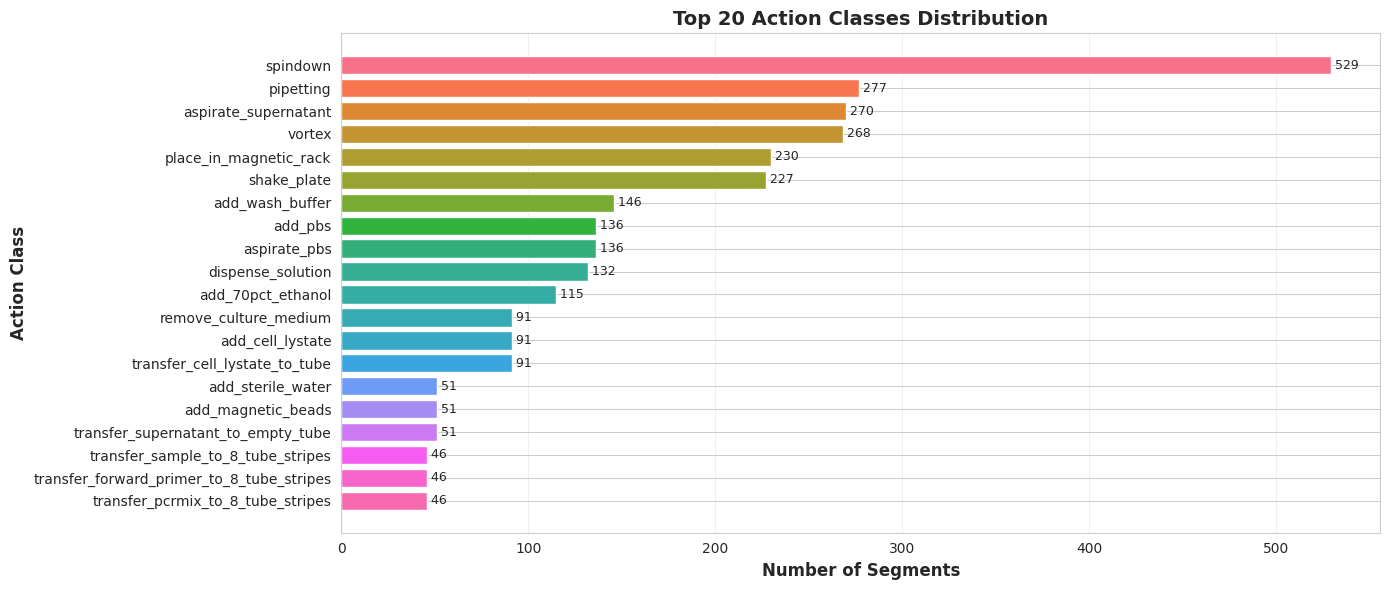

In [14]:
save_path = os.path.join(OUTPUT_ROOT, 'visualizations', 'action_distribution.png')
plot_action_distribution(action_db, top_n=20, save_path=save_path)

The action classes are relevant for a biomedical or molecular biology laboratory setting. They represent standard manual and instrumental operations commonly performed during sample preparation, cell washing, and nucleic acid purification.

Although semantically coherent, some classes may partially overlap (e.g., aspirate_pbs vs aspirate_supernatant), and class consolidation could be considered to enhance dataset balance and model generalization.

In [15]:
def plot_duration_distribution(action_db, save_path=None):
    """
    Visualize segment duration distribution.

    Args:
        action_db: DataFrame with action segments
        save_path: Optional path to save figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(action_db['duration'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Duration (seconds)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0].set_title('Segment Duration Distribution', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Box plot
    axes[1].boxplot(action_db['duration'], vert=True)
    axes[1].set_ylabel('Duration (seconds)', fontsize=12, fontweight='bold')
    axes[1].set_title('Duration Box Plot', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()

Figure saved to: /work/team-ai/IRIS/finebio/videos/processed/visualizations/duration_distribution.png


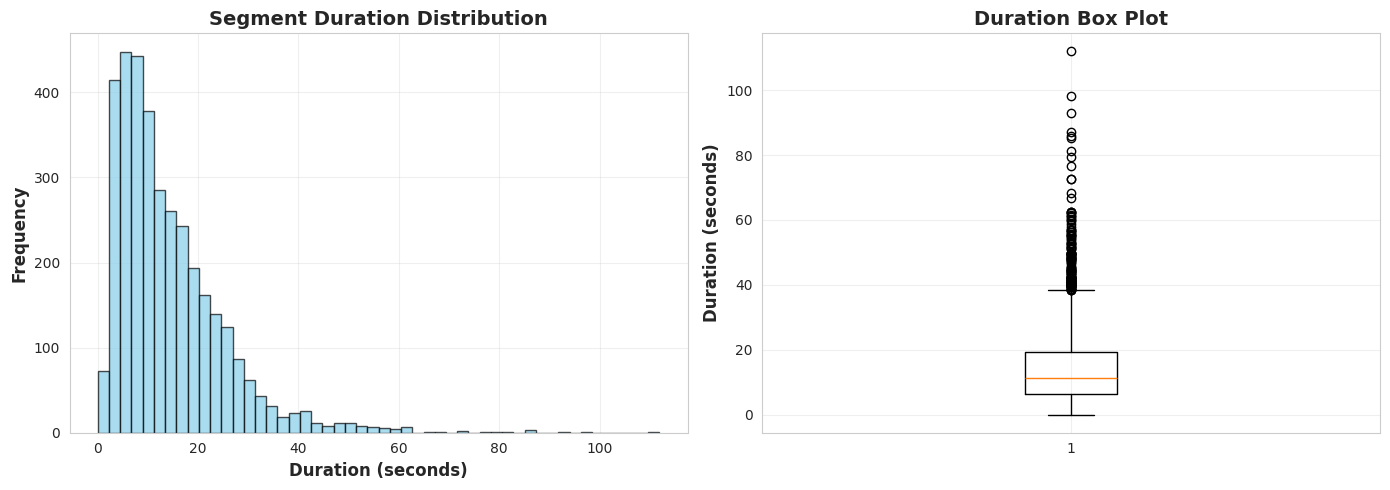

In [16]:
save_path = os.path.join(OUTPUT_ROOT, 'visualizations', 'duration_distribution.png')
plot_duration_distribution(action_db, save_path=save_path)

In [ ]:
print(f"Segment duration statistics (seconds):")
print(action_db['duration'].describe())


Segment duration statistics (seconds):
count    3541.000000
mean       14.286657
std        11.063577
min         0.010000
25%         6.410000
50%        11.330000
75%        19.200000
max       111.910000
Name: duration, dtype: float64


The box plot reveals a highly right-skewed distribution of action segment durations, with a median around 11 seconds (Q1 $\approx$ 6s, Q3 $\approx$ 19s) and numerous outliers. This heterogeneity causes longer actions to contribute disproportionately more clips during training, introducing systematic exposure bias. Duration-normalized strategies may be necessary to ensure balanced representation across action classes.


Number of segments with duration > 45 seconds: 74
Figure saved to: /work/team-ai/IRIS/finebio/videos/processed/visualizations/duration_distribution.png


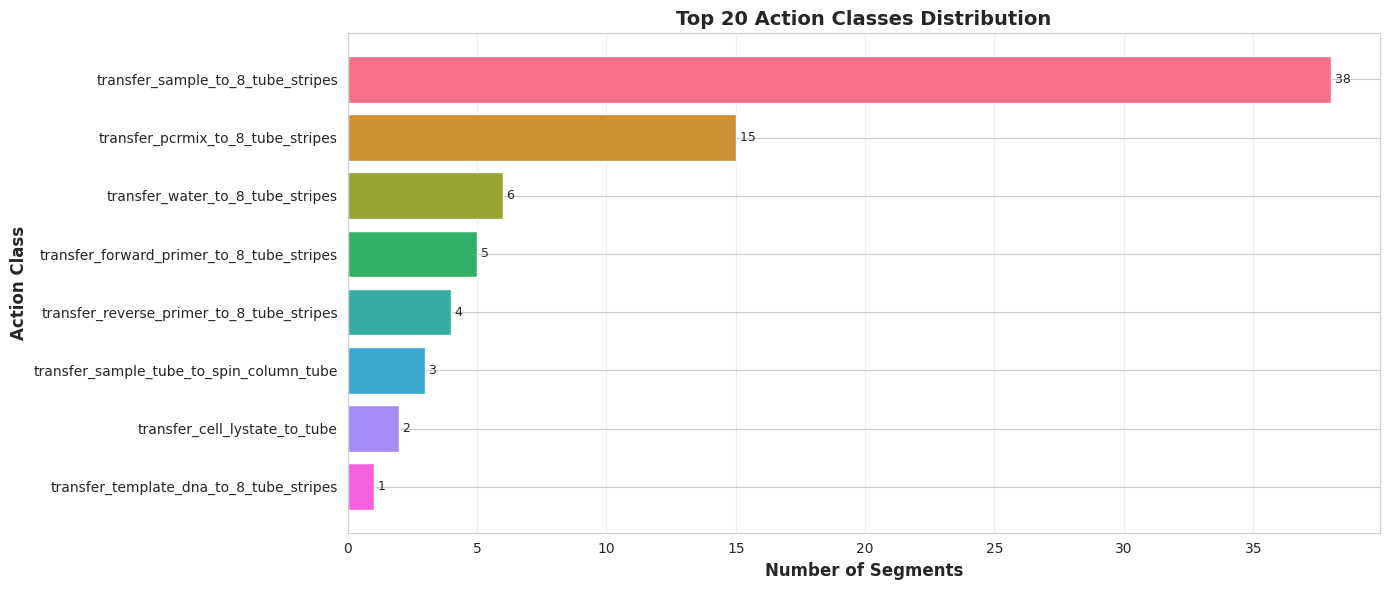

In [ ]:
# Plot the actions classes of the segments having duration more than 45s
long_segments = action_db[action_db['duration'] > 45]
print(f"Number of segments with duration > 45 seconds: {len(long_segments)}")
if len(long_segments) > 0:
    plot_action_distribution(long_segments, top_n=20, save_path=save_path)

Removed proportion of long segments (>45s): 2%


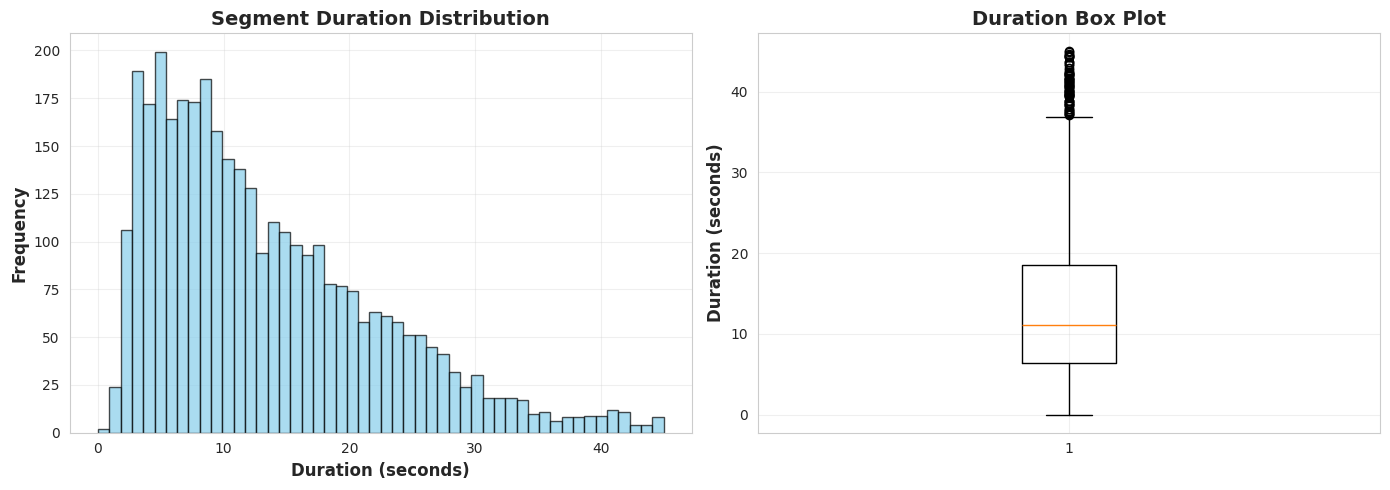

In [19]:
# Removing segments longer than 45s
previous_length = len(action_db)
action_db = action_db[action_db['duration'] <= 45].reset_index(drop=True)
print(f"Removed proportion of long segments (>45s): {1 - len(action_db)/previous_length:.0%}")
plot_duration_distribution(action_db)


Number of segments with duration > 32 seconds: 142
Proportion of segments >32s: 4%
Figure saved to: /work/team-ai/IRIS/finebio/videos/processed/visualizations/duration_distribution.png


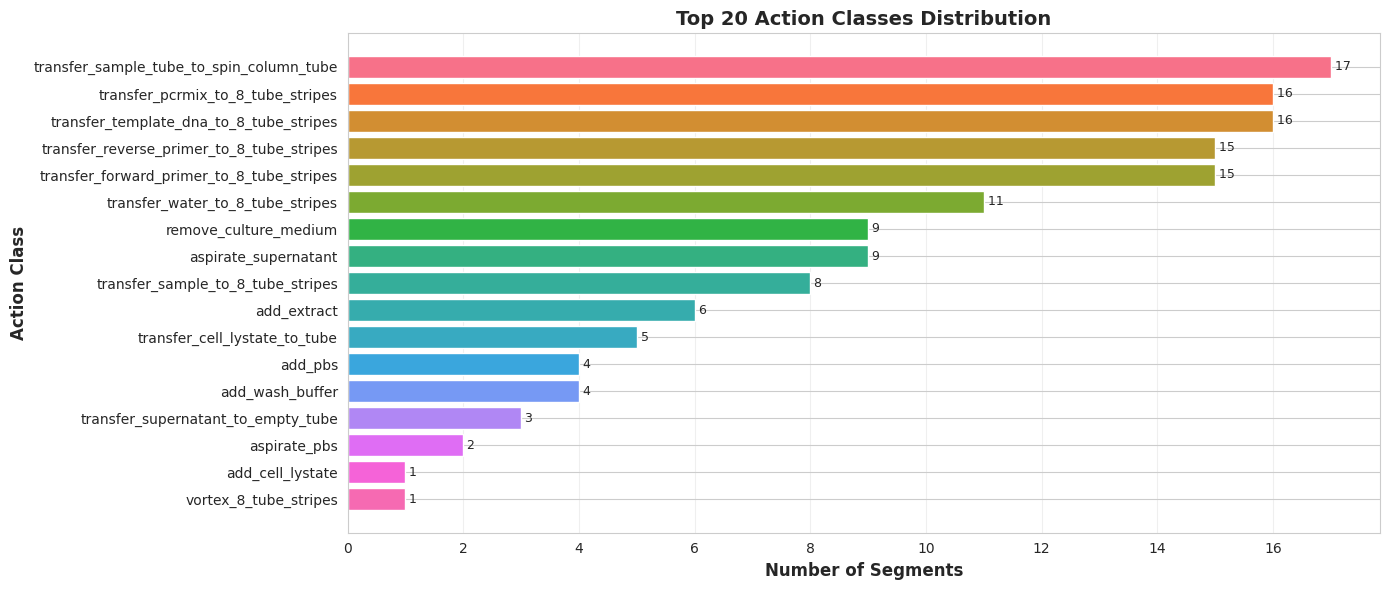

In [ ]:
# Plot the actions classes of the segments having duration more than 32s
long_segments = action_db[action_db['duration'] > 32]
print(f"Number of segments with duration > 32 seconds: {len(long_segments)}")
print(f"Proportion of segments >32s: {len(long_segments)/len(action_db):.0%}")
if len(long_segments) > 0:
    plot_action_distribution(long_segments, top_n=20, save_path=save_path)

In [ ]:
# Number of classes 
count = action_db['action_label'].value_counts()
print(f"Total action classes: {len(count)}")

Total action classes: 32


## 5. Video Preprocessing and Frame Extraction

Extract frames from temporal action segments.

**Frame Sampling Strategy:**
To handle long-duration segments while maintaining consistent temporal coverage:

- **If segment duration < 32 seconds**: Sample 16 frames uniformly across the **entire segment**
- **If segment duration ≥ 32 seconds**: Sample 16 frames uniformly from the **first 32 seconds only**

**Rationale:**
- Prevents over-representation of long actions in the training distribution
- Focuses on the initial phase of extended actions, which often contains the most discriminative information since the actions of these segments are often repetitive

In [ ]:
def get_video_info(video_path):
    """
    Extract metadata from a video file.
    
    Args:
        video_path: Path to the video file
    
    Returns:
        dict: Video metadata (fps, frame_count, duration, width, height)
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        return None
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps if fps > 0 else 0
    
    cap.release()
    
    return {
        'fps': fps,
        'frame_count': frame_count,
        'duration': duration,
        'width': width,
        'height': height
    }


def extract_frames_from_segment(video_path, start_sec, end_sec, num_frames, 
                                 target_size=(224, 224), strategy='uniform', max_duration=32.0):
    """
    Extract frames from a specific temporal segment of a video.
    
    If segment duration >= max_duration (default 32s), only sample from the first max_duration seconds.
    
    Args:
        video_path: Path to the video file
        start_sec: Segment start time in seconds
        end_sec: Segment end time in seconds
        num_frames: Number of frames to extract
        target_size: Target frame size (width, height)
        strategy: Sampling strategy ('uniform' or 'center')
        max_duration: Maximum duration to sample from (default 32 seconds)
    
    Returns:
        list: List of extracted frames as numpy arrays, or None if failed
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        return None
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if fps <= 0:
        cap.release()
        return None
    
    # Calculate segment duration
    segment_duration = end_sec - start_sec
    
    # Apply 32-second cap if segment is longer
    if segment_duration >= max_duration:
        # Sample only from first max_duration seconds
        effective_end_sec = start_sec + max_duration
    else:
        # Use entire segment
        effective_end_sec = end_sec
    
    # Convert time to frame indices
    start_frame = int(start_sec * fps)
    end_frame = int(effective_end_sec * fps)
    
    # Ensure valid frame range
    start_frame = max(0, min(start_frame, total_frames - 1))
    end_frame = max(start_frame + 1, min(end_frame, total_frames))
    
    segment_frames = end_frame - start_frame
    
    if segment_frames < num_frames:
        cap.release()
        return None
    
    # Sample uniformly across the effective segment
    indices = np.linspace(start_frame, end_frame - 1, num_frames, dtype=int)
    
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        
        if not ret:
            cap.release()
            return None
        
        frame = cv2.resize(frame, target_size, interpolation=cv2.INTER_LINEAR)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    
    cap.release()
    return frames


def save_frames_as_images(frames, output_dir, segment_id):
    """
    Save extracted frames as individual image files.
    
    Args:
        frames: List of frame arrays
        output_dir: Directory to save frames
        segment_id: Unique identifier for the segment
    
    Returns:
        str: Path to the frame directory
    """
    frame_dir = os.path.join(output_dir, segment_id)
    os.makedirs(frame_dir, exist_ok=True)
    
    for i, frame in enumerate(frames):
        frame_path = os.path.join(frame_dir, f"frame_{i:04d}.jpg")
        cv2.imwrite(frame_path, cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    
    return frame_dir

## 6. Process All Segments and Generate Metadata

Extract frames from all action segments and create comprehensive metadata.

In [ ]:
def process_action_segments(action_db, output_root, frames_per_clip, frame_size, 
                            min_duration, sampling_strategy, max_duration=32.0):
    """
    Process all action segments and extract frames.
    
    Args:
        action_db: DataFrame with action segments
        output_root: Root directory for processed data
        frames_per_clip: Number of frames to extract per segment
        frame_size: Target frame size (width, height)
        min_duration: Minimum segment duration in seconds
        sampling_strategy: Frame sampling strategy
        max_duration: Maximum duration to sample from (default 32s)
    
    Returns:
        pd.DataFrame: Metadata for all processed clips
    """
    processed_clips = []
    frames_output_dir = os.path.join(output_root, 'frames')
    
    # Create class to label mapping
    action_classes = sorted(action_db['action_label'].unique())
    class_to_label = {name: idx for idx, name in enumerate(action_classes)}
    
    print(f"Total segments to process: {len(action_db)}\n")
    print(f"Total action classes: {len(action_classes)}")

    # Print the mapping of action classes to labels
    print("\nAction class to label mapping:")
    for action_class, label in class_to_label.items():
        print(f"  '{action_class}': {label}")

    
    skipped_segments = []
    
    for idx, row in tqdm(action_db.iterrows(), total=len(action_db), desc="Processing segments"):
        # Skip short segments
        if row['duration'] < min_duration:
            skipped_segments.append((row['segment_id'], f"Too short ({row['duration']:.2f}s < {min_duration}s)"))
            continue
        
        # Extract frames from segment
        frames = extract_frames_from_segment(
            row['video_path'],
            row['start_sec'],
            row['end_sec'],
            frames_per_clip,
            frame_size,
            sampling_strategy,
            max_duration=max_duration
        )
        
        if frames is None:
            skipped_segments.append((row['segment_id'], "Frame extraction failed"))
            continue
        
        frame_dir = save_frames_as_images(frames, frames_output_dir, row['segment_id'])
        
        # Create metadata record
        clip_record = {
            'clip_id': row['segment_id'],
            'video_id': row['video_id'],
            'video_path': row['video_path'],
            'frames_path': frame_dir,
            'action_label': row['action_label'],
            'label': class_to_label[row['action_label']],
            'start_sec': row['start_sec'],
            'end_sec': row['end_sec'],
            'duration': row['duration'],
            'num_frames_extracted': frames_per_clip,
            'target_width': frame_size[0],
            'target_height': frame_size[1],
        }
        
        # Add original annotation columns
        for col in ANNOTATION_COLUMNS:
            if col in row and col not in ['start_sec', 'end_sec']:
                clip_record[col] = row[col]
        
        processed_clips.append(clip_record)
    
    # Create DataFrame
    clips_df = pd.DataFrame(processed_clips)
    
    print(f"Successfully processed: {len(clips_df)} clips")
    print(f"Skipped: {len(skipped_segments)} segments")
    
    return clips_df, class_to_label

In [22]:
# Process all segments
clips_df, class_to_label = process_action_segments(
    action_db,
    OUTPUT_ROOT,
    FRAMES_PER_CLIP,
    FRAME_SIZE,
    MIN_SEGMENT_DURATION,
    SAMPLING_STRATEGY,
    MAX_SEGMENT_DURATION
)

# Display sample metadata
print("\nSample clip metadata:")
print(clips_df[['clip_id', 'action_label', 'label', 'start_sec', 'end_sec', 'duration']].head(10))

# Save complete metadata
metadata_path = os.path.join(OUTPUT_ROOT, 'metadata', 'clips_complete.csv')
clips_df.to_csv(metadata_path, index=False)
print(f"\nComplete clip metadata saved to: {metadata_path}")

# Save class mapping
class_mapping_path = os.path.join(OUTPUT_ROOT, 'metadata', 'class_mapping.json')
with open(class_mapping_path, 'w') as f:
    json.dump(class_to_label, f, indent=2)
print(f"Class mapping saved to: {class_mapping_path}")

Total segments to process: 3467

Total action classes: 32

Action class to label mapping:
  'add_70pct_ethanol': 0
  'add_binding_buffer': 1
  'add_cell_lystate': 2
  'add_extract': 3
  'add_magnetic_beads': 4
  'add_pbs': 5
  'add_sterile_water': 6
  'add_wash_buffer': 7
  'aspirate_pbs': 8
  'aspirate_supernatant': 9
  'close_8_tube_stripes_lid': 10
  'detach_spin_column_and_insert_to_new_tube': 11
  'dispense_solution': 12
  'dispense_spin_column': 13
  'load_8_tube_stripes_to_pcr_machine': 14
  'pipetting': 15
  'place_in_magnetic_rack': 16
  'remove_culture_medium': 17
  'shake_plate': 18
  'spindown': 19
  'spindown_8_tube_stripes': 20
  'transfer_cell_lystate_to_tube': 21
  'transfer_forward_primer_to_8_tube_stripes': 22
  'transfer_pcrmix_to_8_tube_stripes': 23
  'transfer_reverse_primer_to_8_tube_stripes': 24
  'transfer_sample_to_8_tube_stripes': 25
  'transfer_sample_tube_to_spin_column_tube': 26
  'transfer_supernatant_to_empty_tube': 27
  'transfer_template_dna_to_8_tube_s

Processing segments: 100%|██████████| 3467/3467 [4:53:31<00:00,  5.08s/it]  

Successfully processed: 3465 clips
Skipped: 2 segments

Sample clip metadata:
            clip_id                   action_label  label  start_sec  end_sec  \
0  P01_01_01_seg000          remove_culture_medium     17      1.000   20.430   
1  P01_01_01_seg001                        add_pbs      5     23.336   40.650   
2  P01_01_01_seg002                    shake_plate     18     41.218   45.846   
3  P01_01_01_seg003                   aspirate_pbs      8     48.551   61.748   
4  P01_01_01_seg004               add_cell_lystate      2     64.944   83.806   
5  P01_01_01_seg005                    shake_plate     18     84.170   90.610   
6  P01_01_01_seg006  transfer_cell_lystate_to_tube     21     90.710  113.522   
7  P01_01_01_seg007                       spindown     19    113.571  123.689   
8  P01_01_01_seg008           aspirate_supernatant      9    124.320  143.764   
9  P01_01_02_seg000          remove_culture_medium     17      1.000   19.250   

   duration  
0    19.430  
1 

### Display segment duration capping statistics


In [23]:
print("SEGMENT DURATION ANALYSIS:")

# Count segments that would have been capped
long_segments = clips_df[clips_df['duration'] >= MAX_SEGMENT_DURATION]
total_segments = len(clips_df)
capped_count = len(long_segments)
capped_percentage = (capped_count / total_segments * 100) if total_segments > 0 else 0

print(f"Total processed clips: {total_segments}")
print(f"Segments >= {MAX_SEGMENT_DURATION}s (capped to first {MAX_SEGMENT_DURATION}s): {capped_count} ({capped_percentage:.1f}%)")
print(f"Segments < {MAX_SEGMENT_DURATION}s (sampled fully): {total_segments - capped_count} ({100-capped_percentage:.1f}%)")

if capped_count > 0:
    print(f"\nCapped segments statistics:")
    print(f"  Original duration range: {long_segments['duration'].min():.1f}s - {long_segments['duration'].max():.1f}s")
    print(f"  Mean original duration: {long_segments['duration'].mean():.1f}s")
    print(f"  After capping: All sampled from first {MAX_SEGMENT_DURATION}s")
    
    print(f"\nTop action classes affected by capping:")
    print(long_segments['action_label'].value_counts().head(10))

SEGMENT DURATION ANALYSIS:
Total processed clips: 3465
Segments >= 32.0s (capped to first 32.0s): 143 (4.1%)
Segments < 32.0s (sampled fully): 3322 (95.9%)

Capped segments statistics:
  Original duration range: 32.0s - 45.0s
  Mean original duration: 37.4s
  After capping: All sampled from first 32.0s

Top action classes affected by capping:
action_label
transfer_pcrmix_to_8_tube_stripes            17
transfer_sample_tube_to_spin_column_tube     17
transfer_template_dna_to_8_tube_stripes      16
transfer_reverse_primer_to_8_tube_stripes    15
transfer_forward_primer_to_8_tube_stripes    15
transfer_water_to_8_tube_stripes             11
remove_culture_medium                         9
aspirate_supernatant                          9
transfer_sample_to_8_tube_stripes             8
add_extract                                   6
Name: count, dtype: int64


### Display Processed Data Statistics

In [24]:
print("PROCESSED CLIPS STATISTICS:")
print(f"Total processed clips: {len(clips_df)}")
print(f"Number of action classes: {clips_df['label'].nunique()}")
print(f"Number of source videos: {clips_df['video_id'].nunique()}")
print(f"\nClips per action class:")
print(clips_df['action_label'].value_counts().head(20))
print(f"\nClip duration statistics:")
print(clips_df['duration'].describe())

PROCESSED CLIPS STATISTICS:
Total processed clips: 3465
Number of action classes: 32
Number of source videos: 226

Clips per action class:
action_label
spindown                              529
pipetting                             277
aspirate_supernatant                  269
vortex                                268
place_in_magnetic_rack                229
shake_plate                           227
add_wash_buffer                       146
add_pbs                               136
aspirate_pbs                          136
dispense_solution                     132
add_70pct_ethanol                     115
remove_culture_medium                  91
add_cell_lystate                       91
transfer_cell_lystate_to_tube          89
add_sterile_water                      51
add_magnetic_beads                     51
transfer_supernatant_to_empty_tube     51
vortex_8_tube_stripes                  46
close_8_tube_stripes_lid               46
spindown_8_tube_stripes                46
Name: co

## 7. Train/Validation/Test Split

**IMPORTANT**: Split by video ID to prevent data leakage. All clips from the same video go into the same split.

In [25]:
def create_video_level_splits(clips_df, train_ratio, val_ratio, test_ratio, random_seed):
    """
    Create train/val/test splits at the video level (no data leakage).
    
    Args:
        clips_df: DataFrame with clip metadata
        train_ratio: Proportion for training set
        val_ratio: Proportion for validation set
        test_ratio: Proportion for test set
        random_seed: Random seed for reproducibility
    
    Returns:
        tuple: (train_df, val_df, test_df)
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1.0"
    
    unique_videos = clips_df['video_id'].unique()
    
    np.random.seed(random_seed)
    shuffled_videos = np.random.permutation(unique_videos)
    
    n_videos = len(shuffled_videos)
    train_end = int(n_videos * train_ratio)
    val_end = int(n_videos * (train_ratio + val_ratio))
    
    train_videos = set(shuffled_videos[:train_end])
    val_videos = set(shuffled_videos[train_end:val_end])
    test_videos = set(shuffled_videos[val_end:])
    
    train_df = clips_df[clips_df['video_id'].isin(train_videos)].copy()
    val_df = clips_df[clips_df['video_id'].isin(val_videos)].copy()
    test_df = clips_df[clips_df['video_id'].isin(test_videos)].copy()
    
    return train_df, val_df, test_df

In [26]:
train_df, val_df, test_df = create_video_level_splits(
    clips_df,
    TRAIN_RATIO,
    VAL_RATIO,
    TEST_RATIO,
    RANDOM_SEED
)

# Add split column to original dataframe
clips_df['split'] = 'unknown'
clips_df.loc[train_df.index, 'split'] = 'train'
clips_df.loc[val_df.index, 'split'] = 'val'
clips_df.loc[test_df.index, 'split'] = 'test'

# Save split datasets
train_path = os.path.join(OUTPUT_ROOT, 'metadata', 'train.csv')
val_path = os.path.join(OUTPUT_ROOT, 'metadata', 'val.csv')
test_path = os.path.join(OUTPUT_ROOT, 'metadata', 'test.csv')
clips_complete_path = os.path.join(OUTPUT_ROOT, 'metadata', 'clips_complete.csv')

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)
clips_df.to_csv(clips_complete_path, index=False)

print(f"Split files saved:")
print(f"  Train: {train_path}")
print(f"  Val: {val_path}")
print(f"  Test: {test_path}")

Split files saved:
  Train: /work/team-ai/IRIS/finebio/videos/processed/metadata/train.csv
  Val: /work/team-ai/IRIS/finebio/videos/processed/metadata/val.csv
  Test: /work/team-ai/IRIS/finebio/videos/processed/metadata/test.csv


### Display split statistics

In [27]:
print("SPLIT STATISTICS:")

print("\nClips per split:")
print(f"  Train: {len(train_df)} clips ({len(train_df)/len(clips_df)*100:.1f}%)")
print(f"  Val:   {len(val_df)} clips ({len(val_df)/len(clips_df)*100:.1f}%)")
print(f"  Test:  {len(test_df)} clips ({len(test_df)/len(clips_df)*100:.1f}%)")

print("\nVideos per split:")
print(f"  Train: {train_df['video_id'].nunique()} videos")
print(f"  Val:   {val_df['video_id'].nunique()} videos")
print(f"  Test:  {test_df['video_id'].nunique()} videos")

print("\nAction class distribution per split:")
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{split_name}: {split_df['action_label'].nunique()} unique classes")
    print(split_df['action_label'].value_counts().head(10))

# Verify no video leakage
train_videos = set(train_df['video_id'].unique())
val_videos = set(val_df['video_id'].unique())
test_videos = set(test_df['video_id'].unique())

assert len(train_videos & val_videos) == 0, "ERROR: Video leakage between train and val!"
assert len(train_videos & test_videos) == 0, "ERROR: Video leakage between train and test!"
assert len(val_videos & test_videos) == 0, "ERROR: Video leakage between val and test!"

print("Verified: No video leakage between splits!")

SPLIT STATISTICS:

Clips per split:
  Train: 2371 clips (68.4%)
  Val:   574 clips (16.6%)
  Test:  520 clips (15.0%)

Videos per split:
  Train: 158 videos
  Val:   34 videos
  Test:  34 videos

Action class distribution per split:

Train: 32 unique classes
action_label
spindown                  357
aspirate_supernatant      176
pipetting                 171
vortex                    170
shake_plate               169
place_in_magnetic_rack    142
aspirate_pbs              103
add_pbs                   103
add_wash_buffer           100
dispense_solution          94
Name: count, dtype: int64

Val: 32 unique classes
action_label
spindown                  85
pipetting                 62
vortex                    55
aspirate_supernatant      53
place_in_magnetic_rack    51
shake_plate               31
add_70pct_ethanol         22
add_wash_buffer           20
add_pbs                   18
aspirate_pbs              18
Name: count, dtype: int64

Test: 31 unique classes
action_label
spindown   

### Visualize Split Distribution

In [28]:
def plot_split_distribution(train_df, val_df, test_df, top_n=15, save_path=None):
    """
    Visualize the distribution of action classes across train/val/test splits.
    """
    # Get top N classes from training set
    top_classes = train_df['action_label'].value_counts().head(top_n).index
    
    train_counts = [len(train_df[train_df['action_label'] == c]) for c in top_classes]
    val_counts = [len(val_df[val_df['action_label'] == c]) for c in top_classes]
    test_counts = [len(test_df[test_df['action_label'] == c]) for c in top_classes]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    bar_width = 0.25
    x = np.arange(len(top_classes))
    
    bars1 = ax.bar(x - bar_width, train_counts, bar_width, label='Train', color='#3498db')
    bars2 = ax.bar(x, val_counts, bar_width, label='Val', color='#e74c3c')
    bars3 = ax.bar(x + bar_width, test_counts, bar_width, label='Test', color='#2ecc71')
    
    ax.set_xlabel('Action Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Clips', fontsize=12, fontweight='bold')
    ax.set_title(f'Dataset Split Distribution (Top {top_n} Classes)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(top_classes, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()

Figure saved to: /work/team-ai/IRIS/finebio/videos/processed/visualizations/split_distribution.png


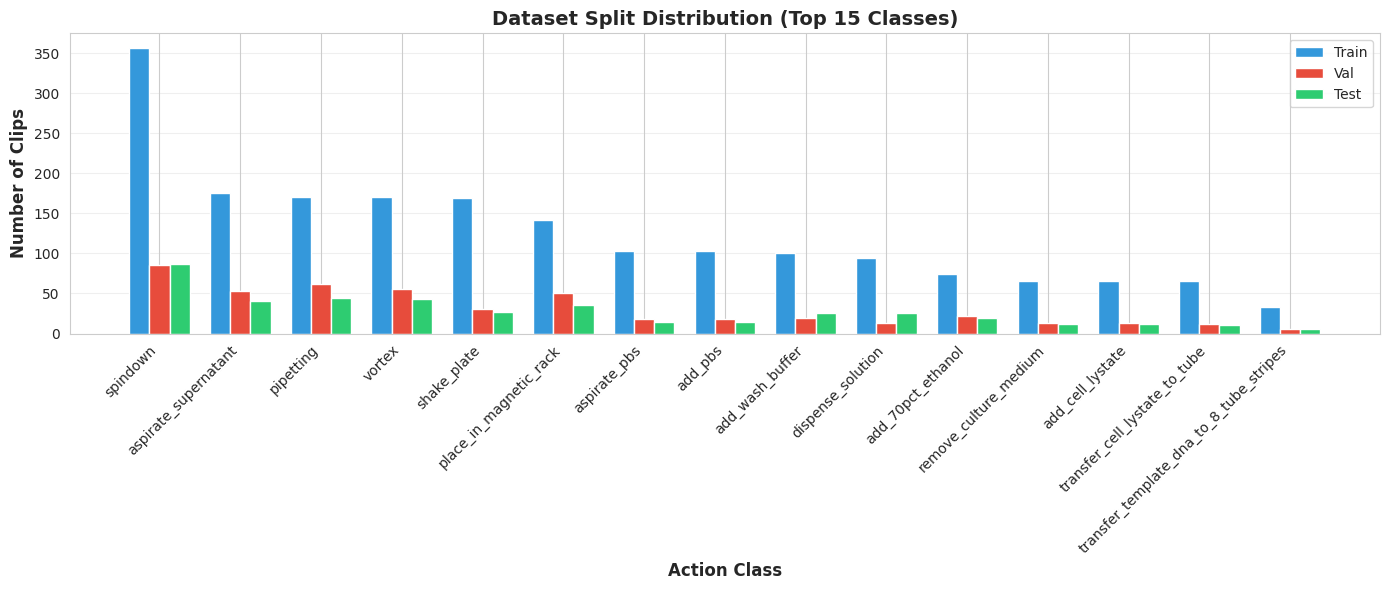

In [29]:
save_path = os.path.join(OUTPUT_ROOT, 'visualizations', 'split_distribution.png')
plot_split_distribution(train_df, val_df, test_df, top_n=15, save_path=save_path)

## 8. Data Verification

### Verify Frame Quality

In [ ]:
def verify_frame_quality(clips_df, num_checks=10):
    """
    Verify that saved frames match expected specifications.
    """

    sample_clips = clips_df.sample(n=min(num_checks, len(clips_df)), random_state=RANDOM_SEED)
    all_passed = True
    
    for idx, row in sample_clips.iterrows():
        frames_dir = row['frames_path']
        frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.jpg')])
        
        # Check number of frames
        if len(frame_files) != FRAMES_PER_CLIP:
            print(f"{row['clip_id']}: Expected {FRAMES_PER_CLIP} frames, found {len(frame_files)}")
            all_passed = False
            continue
        
        # Check first frame dimensions
        first_frame_path = os.path.join(frames_dir, frame_files[0])
        frame = cv2.imread(first_frame_path)
        
        if frame.shape[:2] != (FRAME_SIZE[1], FRAME_SIZE[0]):
            print(f"{row['clip_id']}: Expected size {FRAME_SIZE}, found {frame.shape[:2][::-1]}")
            all_passed = False
            continue
        
        print(f"{row['clip_id']}: {len(frame_files)} frames @ {frame.shape[:2][::-1]}")
    
    if all_passed:
        print("All quality checks passed!")
    else:
        print("Some quality checks failed. Please review above.")

# Run quality verification
verify_frame_quality(clips_df, num_checks=15)

P27_07_01_seg015: 16 frames @ (224, 224)
P03_03_01_seg024: 16 frames @ (224, 224)
P28_07_01_seg019: 16 frames @ (224, 224)
P14_01_01_seg000: 16 frames @ (224, 224)
P10_02_01_seg010: 16 frames @ (224, 224)
P17_05_02_seg001: 16 frames @ (224, 224)
P10_07_01_seg012: 16 frames @ (224, 224)
P02_02_01_seg002: 16 frames @ (224, 224)
P06_04_02_seg004: 16 frames @ (224, 224)
P02_04_02_seg004: 16 frames @ (224, 224)
P01_03_01_seg009: 16 frames @ (224, 224)
P20_05_01_seg006: 16 frames @ (224, 224)
P29_01_01_seg003: 16 frames @ (224, 224)
P11_03_01_seg001: 16 frames @ (224, 224)
P23_03_01_seg002: 16 frames @ (224, 224)
All quality checks passed!


## 9. Summary

In [ ]:
class_to_label_path = os.path.join(OUTPUT_ROOT, 'metadata', 'class_mapping.json')
with open(class_to_label_path, 'r') as f:
    class_to_label = json.load(f)
clips_df = pd.read_csv(os.path.join(OUTPUT_ROOT, 'metadata', 'clips_complete.csv'))
train_df = pd.read_csv(os.path.join(OUTPUT_ROOT, 'metadata', 'train.csv'))
val_df = pd.read_csv(os.path.join(OUTPUT_ROOT, 'metadata', 'val.csv'))
test_df = pd.read_csv(os.path.join(OUTPUT_ROOT, 'metadata', 'test.csv'))

print("DATA PROCESSING PIPELINE SUMMARY:")

print("\n1. DATASET OVERVIEW")
print(f"   Total action classes: {len(class_to_label)}")
print(f"   Total processed clips: {len(clips_df)}")
print(f"   Total source videos: {clips_df['video_id'].nunique()}")
print(f"   Label column used: {LABEL_COLUMN}")
print(f"   Frame extraction: {FRAMES_PER_CLIP} frames per clip @ {FRAME_SIZE}")
print(f"   Sampling strategy: {SAMPLING_STRATEGY}")

print("\n2. DATASET SPLITS (Video-Level - No Leakage)")
print(f"   Train: {len(train_df)} clips from {train_df['video_id'].nunique()} videos ({len(train_df)/len(clips_df)*100:.1f}%)")
print(f"   Val:   {len(val_df)} clips from {val_df['video_id'].nunique()} videos ({len(val_df)/len(clips_df)*100:.1f}%)")
print(f"   Test:  {len(test_df)} clips from {test_df['video_id'].nunique()} videos ({len(test_df)/len(clips_df)*100:.1f}%)")

print("\n3. OUTPUT FILES")
print(f"   Frames directory: {os.path.join(OUTPUT_ROOT, 'frames')}")
print(f"   Metadata directory: {os.path.join(OUTPUT_ROOT, 'metadata')}")
print(f"   - clips_complete.csv: All clips with split info")
print(f"   - train.csv: Training set metadata ({len(train_df)} clips)")
print(f"   - val.csv: Validation set metadata ({len(val_df)} clips)")
print(f"   - test.csv: Test set metadata ({len(test_df)} clips)")
print(f"   - class_mapping.json: Action class to label mapping")

print("\n4. TOP 10 ACTION CLASSES")
action_counts = clips_df['action_label'].value_counts().head(10)
for i, (action, count) in enumerate(action_counts.items(), 1):
    label = class_to_label[action]
    print(f"   {label:3d}. {action:40s} : {count:4d} clips")

print("\nPipeline completed successfully!")

DATA PROCESSING PIPELINE SUMMARY:

1. DATASET OVERVIEW
   Total action classes: 32
   Total processed clips: 3465
   Total source videos: 226
   Label column used: task
   Frame extraction: 16 frames per clip @ (224, 224)
   Sampling strategy: uniform

2. DATASET SPLITS (Video-Level - No Leakage)
   Train: 2371 clips from 158 videos (68.4%)
   Val:   574 clips from 34 videos (16.6%)
   Test:  520 clips from 34 videos (15.0%)

3. OUTPUT FILES
   Frames directory: /work/team-ai/IRIS/finebio/videos/processed/frames
   Metadata directory: /work/team-ai/IRIS/finebio/videos/processed/metadata
   - clips_complete.csv: All clips with split info
   - train.csv: Training set metadata (2371 clips)
   - val.csv: Validation set metadata (574 clips)
   - test.csv: Test set metadata (520 clips)
   - class_mapping.json: Action class to label mapping

4. TOP 10 ACTION CLASSES
    19. spindown                                 :  529 clips
    15. pipetting                                :  277 clips
    

## 10. Save Processing Configuration

In [33]:
config = {
    'dataset_root': DATASET_ROOT,
    'output_root': OUTPUT_ROOT,
    'label_column': LABEL_COLUMN,
    'annotation_columns': ANNOTATION_COLUMNS,
    'target_fps': TARGET_FPS,
    'frames_per_clip': FRAMES_PER_CLIP,
    'min_segment_duration': MIN_SEGMENT_DURATION,
    'max_segment_duration': MAX_SEGMENT_DURATION,
    'frame_size': FRAME_SIZE,
    'sampling_strategy': SAMPLING_STRATEGY,
    'train_ratio': TRAIN_RATIO,
    'val_ratio': VAL_RATIO,
    'test_ratio': TEST_RATIO,
    'random_seed': RANDOM_SEED,
    'num_classes': len(class_to_label),
    'total_clips': len(clips_df),
    'total_videos': clips_df['video_id'].nunique(),
    'train_clips': len(train_df),
    'val_clips': len(val_df),
    'test_clips': len(test_df),
    'train_videos': train_df['video_id'].nunique(),
    'val_videos': val_df['video_id'].nunique(),
    'test_videos': test_df['video_id'].nunique(),
}

config_path = os.path.join(OUTPUT_ROOT, 'metadata', 'processing_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"Processing configuration saved to: {config_path}")
print("\nConfiguration:")
print(json.dumps(config, indent=2))

Processing configuration saved to: /work/team-ai/IRIS/finebio/videos/processed/metadata/processing_config.json

Configuration:
{
  "dataset_root": "/work/team-ai/IRIS/finebio/videos/w640",
  "output_root": "/work/team-ai/IRIS/finebio/videos/processed",
  "label_column": "task",
  "annotation_columns": [
    "start_sec",
    "end_sec",
    "task",
    "hand_side",
    "verb",
    "manipulated_object",
    "affected_object"
  ],
  "target_fps": 1,
  "frames_per_clip": 16,
  "min_segment_duration": 1.0,
  "max_segment_duration": 32.0,
  "frame_size": [
    224,
    224
  ],
  "sampling_strategy": "uniform",
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "random_seed": 42,
  "num_classes": 32,
  "total_clips": 3465,
  "total_videos": 226,
  "train_clips": 2371,
  "val_clips": 574,
  "test_clips": 520,
  "train_videos": 158,
  "val_videos": 34,
  "test_videos": 34
}


## 11. Convert CSV to VideoMAE-v2 Format

Convert the generated CSV files to the format expected by `RawFrameClsDataset` in VideoMAE-v2.

**Format required:**
```
relative_path num_frames label
```

Example:
```
P01_01_01_seg000 16 0
P01_01_01_seg001 16 1
```

**Important:** No header, space-delimited, relative paths from `data_root/frames/`

In [34]:
def convert_csv_to_videomae_format(input_csv, output_csv, data_root):
    """
    Convert CSV to VideoMAE-v2 RawFrameClsDataset format.
    
    Args:
        input_csv: Path to input CSV (train.csv, val.csv, test.csv)
        output_csv: Path to output CSV in VideoMAE-v2 format
        data_root: Root directory of processed data
    """
    df = pd.read_csv(input_csv)
    
    videomae_rows = []
    
    for idx, row in df.iterrows():
        frames_path = row['frames_path']
        
        frames_root = os.path.join(data_root, 'frames')
        relative_path = os.path.relpath(frames_path, frames_root)
        
        num_frames = int(row['num_frames_extracted'])
        label = int(row['label'])
        
        videomae_row = f"{relative_path} {num_frames} {label}"
        videomae_rows.append(videomae_row)
    
    with open(output_csv, 'w') as f:
        for row in videomae_rows:
            f.write(row + '\n')
    
    print(f"Converted {len(videomae_rows)} samples: {input_csv} → {output_csv}")
    print(f"Example: {videomae_rows[0]}")

In [35]:
# Convert all splits
for split in ['train', 'val', 'test']:
    input_csv = os.path.join(OUTPUT_ROOT, 'metadata', f'{split}.csv')
    output_csv = os.path.join(OUTPUT_ROOT, 'metadata', f'{split}_videomae.txt')
    
    if os.path.exists(input_csv):
        convert_csv_to_videomae_format(input_csv, output_csv, OUTPUT_ROOT)
    else:
        print(f"Warning: {input_csv} not found")

print("\nCSV CONVERSION COMPLETED!")
print("\nFiles created for VideoMAE-v2 training:")
print(f"  - {os.path.join(OUTPUT_ROOT, 'metadata', 'train_videomae.txt')}")
print(f"  - {os.path.join(OUTPUT_ROOT, 'metadata', 'val_videomae.txt')}")
print(f"  - {os.path.join(OUTPUT_ROOT, 'metadata', 'test_videomae.txt')}")
print("\nUse these files in your SLURM script with:")
print(f"  --data_path {os.path.join(OUTPUT_ROOT, 'metadata')}")
print(f"  --data_root {os.path.join(OUTPUT_ROOT, 'frames')}")
print(f"  --data_set FineBio")
print(f"  --nb_classes {len(class_to_label)}")

Converted 2371 samples: /work/team-ai/IRIS/finebio/videos/processed/metadata/train.csv → /work/team-ai/IRIS/finebio/videos/processed/metadata/train_videomae.txt
Example: P01_01_01_seg000 16 17
Converted 574 samples: /work/team-ai/IRIS/finebio/videos/processed/metadata/val.csv → /work/team-ai/IRIS/finebio/videos/processed/metadata/val_videomae.txt
Example: P01_04_02_seg000 16 4
Converted 520 samples: /work/team-ai/IRIS/finebio/videos/processed/metadata/test.csv → /work/team-ai/IRIS/finebio/videos/processed/metadata/test_videomae.txt
Example: P01_01_02_seg000 16 17

CSV CONVERSION COMPLETED!

Files created for VideoMAE-v2 training:
  - /work/team-ai/IRIS/finebio/videos/processed/metadata/train_videomae.txt
  - /work/team-ai/IRIS/finebio/videos/processed/metadata/val_videomae.txt
  - /work/team-ai/IRIS/finebio/videos/processed/metadata/test_videomae.txt

Use these files in your SLURM script with:
  --data_path /work/team-ai/IRIS/finebio/videos/processed/metadata
  --data_root /work/team-a